# 02 — Exploratory Data Analysis: Volatility Stylised Facts

This notebook explores the volatility panel constructed in notebook 01. It is descriptive rather than confirmatory: its role is to establish the empirical properties of the volatility proxies and, in doing so, to justify each modelling choice made in the formal transfer-entropy and Granger-causality analysis that follows.

- **Distributional properties** decide whether the data are non-Gaussian — the precondition under which transfer entropy carries information beyond linear Granger causality (Barnett, Barrett & Seth 2009), and the justification for the Student-*t* innovations used in the GARCH fits.
- **Asymmetry** decides which conditional-volatility proxy each channel should use (GARCH vs EGARCH).
- **Stationarity** checks the precondition for Granger causality and transfer entropy.
- **Slow decay / long memory** grounds the choice of a daily sampling frequency.
- **Contemporaneous and lead–lag structure** motivates why a directional, non-linear method is needed at all, rather than same-day correlation.

**Proxy usage.** Three volatility representations are available per series: model-free absolute innovation, GARCH(1,1) conditional volatility, and EGARCH(1,1) conditional volatility. They are used by role: absolute innovation for the model-free descriptive facts (clustering, long memory), and the conditional-volatility proxies where the analysis needs to mirror what the formal causality tests will actually consume.

In [36]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

PROJECT_NAME = "Volatility_Project"
def find_project_root(name, start=None):
    start = Path(start or Path.cwd()).resolve()
    for c in [start] + list(start.parents):
        if c.name == name:
            return c
    raise FileNotFoundError(f"Could not find '{name}' above {start}; hard-code BASE.")

BASE = find_project_root(PROJECT_NAME)
PROCESSED_DIR = BASE / "data" / "processed"
FIGURES_DIR   = BASE / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

wide = pd.read_csv(PROCESSED_DIR / "master_panel_wide.csv", parse_dates=["Date"])
model_summary = pd.read_csv(PROCESSED_DIR / "garch_egarch_summary.csv", index_col="series")

print("Panel:", wide.shape, "|", wide["Date"].min().date(), "->", wide["Date"].max().date())

Panel: (2595, 95) | 2015-01-02 -> 2024-12-31


In [37]:
# Innovation series (raw return / change) behind each volatility proxy.
innovation = {
    "EURUSD": "EURUSD_Return", "USDJPY": "USDJPY_Return",
    "AUDUSD": "AUDUSD_Return", "USDCAD": "USDCAD_Return",
    "US_DE_2Y_Diff": "US_DE_2Y_Diff_Change_bp",
    "US_JP_2Y_Diff": "US_JP_2Y_Diff_Change_bp",
    "US2Y": "US2Y_Change_bp", "DE2Y": "DE2Y_Change_bp", "JP2Y": "JP2Y_Change_bp",
    "Brent": "Brent_Return", "Gold": "Gold_Return", "Silver": "Silver_Return",
}

# Channel design: each FX pair paired with its primary transmission source.
# USDJPY's safe-haven link to gold is examined only as a robustness aside, not a primary channel.
channels = {
    "EURUSD": "US_DE_2Y_Diff",   # rates channel
    "USDJPY": "US_JP_2Y_Diff",   # rates channel
    "AUDUSD": "Gold",            # commodity channel (metals; Silver as secondary)
    "USDCAD": "Brent",           # commodity channel (oil)
}

# Representative series for figures; full series covered in tables.
rep_fx    = ["EURUSD", "USDJPY"]
rep_rates = ["US_DE_2Y_Diff"]
rep_comm  = ["Brent", "Gold"]
representative = rep_fx + rep_rates + rep_comm
print("Representative series for plots:", representative)

Representative series for plots: ['EURUSD', 'USDJPY', 'US_DE_2Y_Diff', 'Brent', 'Gold']


## 1. Volatility time series

Two views. First, each FX pair's volatility is plotted against its transmission source, to see whether turbulent periods coincide across markets — the visual precursor to the transmission question. Second, for a single series the three proxies (absolute innovation, GARCH, EGARCH conditional volatility) are overlaid, to confirm the model-based proxies smooth the raw magnitude rather than distort it.

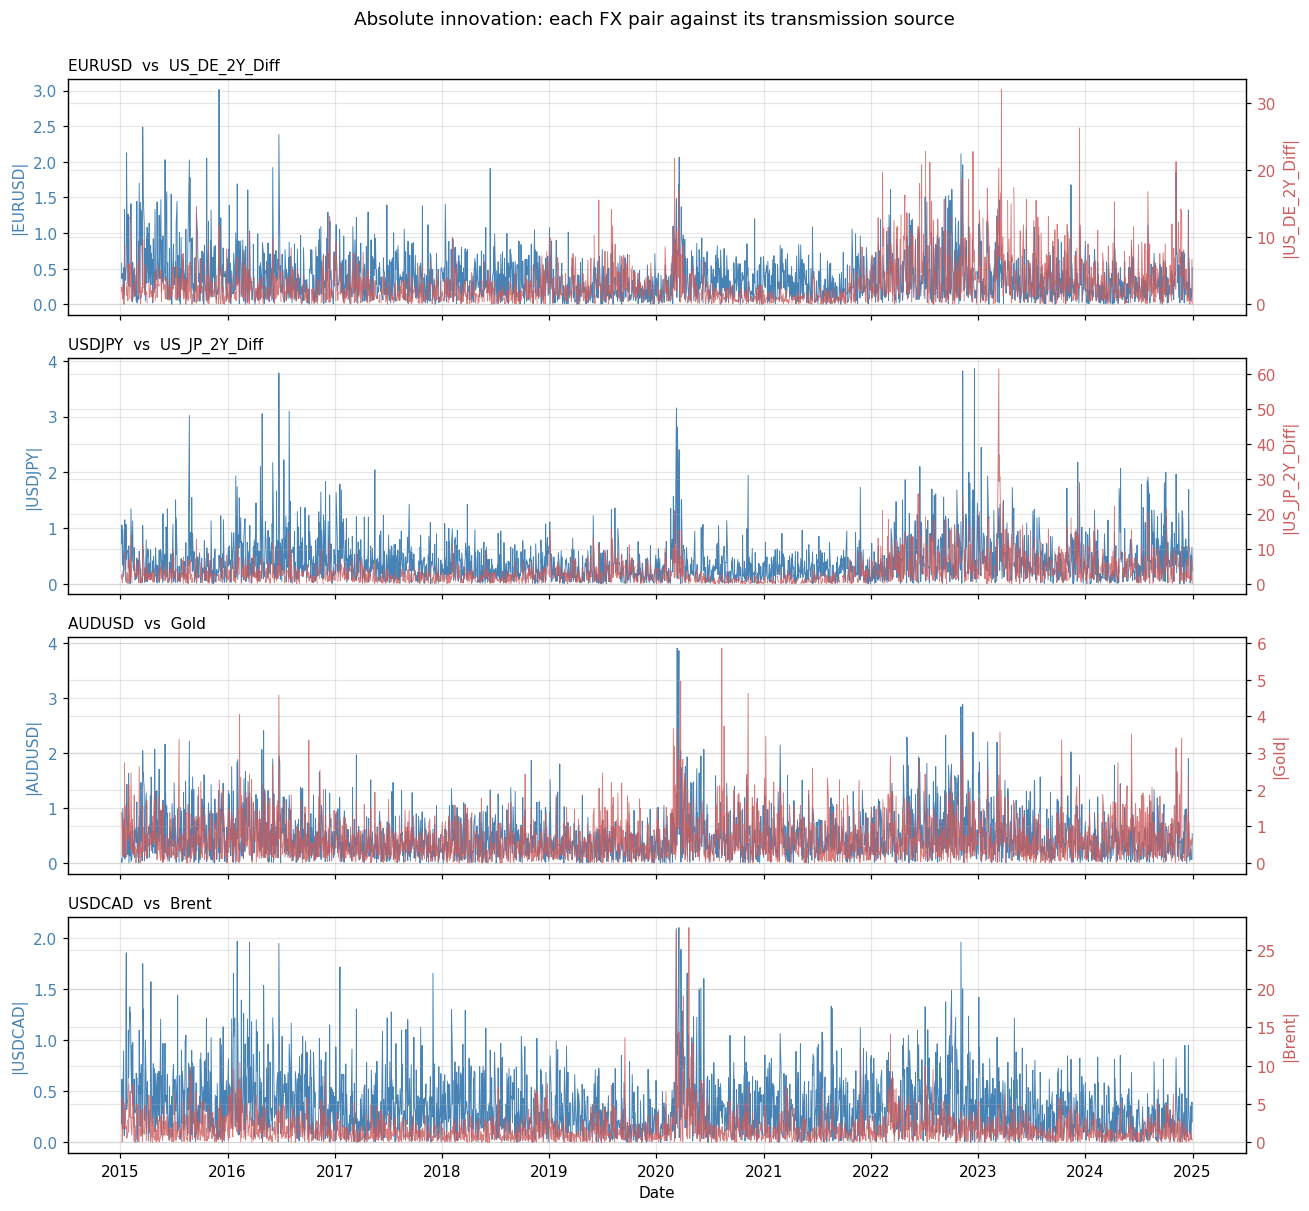

In [38]:
# View 1: each FX pair's |innovation| against its source's |innovation|.
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
for ax, (fx, src) in zip(axes, channels.items()):
    axR = ax.twinx()
    ax.plot(wide["Date"], wide[f"{fx}_abs"], lw=0.6, color="steelblue", label=f"|{fx}|")
    axR.plot(wide["Date"], wide[f"{src}_abs"], lw=0.6, color="indianred", alpha=0.8, label=f"|{src}|")
    ax.set_ylabel(f"|{fx}|", color="steelblue")
    axR.set_ylabel(f"|{src}|", color="indianred")
    ax.tick_params(axis="y", labelcolor="steelblue")
    axR.tick_params(axis="y", labelcolor="indianred")
    ax.set_title(f"{fx}  vs  {src}", loc="left", fontsize=10)
axes[-1].set_xlabel("Date")
fig.suptitle("Absolute innovation: each FX pair against its transmission source", y=0.997)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_vol_fx_vs_source.png", dpi=130, bbox_inches="tight")
plt.show()

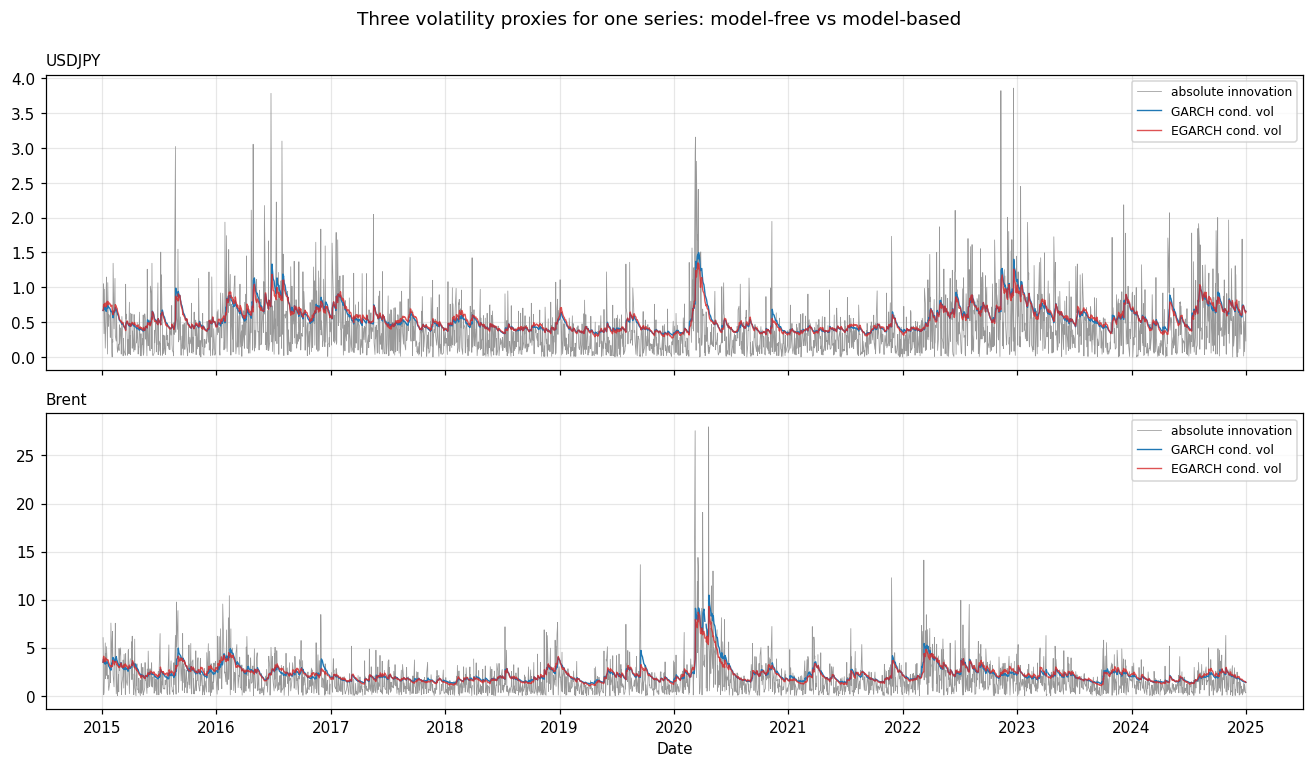

In [39]:
# View 2: three proxies overlaid for one representative series.
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, name in zip(axes, ["USDJPY", "Brent"]):
    ax.plot(wide["Date"], wide[f"{name}_abs"], lw=0.5, color="0.6", label="absolute innovation")
    ax.plot(wide["Date"], wide[f"{name}_garchvol"], lw=0.9, color="C0", label="GARCH cond. vol")
    ax.plot(wide["Date"], wide[f"{name}_egarchvol"], lw=0.9, color="C3", alpha=0.8, label="EGARCH cond. vol")
    ax.set_title(name, loc="left", fontsize=10)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Date")
fig.suptitle("Three volatility proxies for one series: model-free vs model-based", y=0.99)
fig.tight_layout()
plt.show()

The turbulent bands in the first figure line up across markets — a rates-channel pair such as EURUSD spikes when the US–DE differential spikes, and the commodity pairs spike with their benchmarks — most visibly around March 2020 and the 2022–2023 rate cycle. This shared timing is what the transmission analysis will formalise. The second figure shows the GARCH and EGARCH conditional volatilities tracing a smoothed path through the noisy absolute innovation without changing its overall shape, confirming the model-based proxies clean the series rather than reshape it.

## 2. Distributional properties

The distribution of the innovations matters for two later decisions. It determines whether Student-*t* innovations were the right choice for the GARCH fits, and — more consequentially — whether the data are non-Gaussian at all. Barnett, Barrett & Seth (2009) prove that transfer entropy and linear Granger causality are equivalent for Gaussian variables, so any added value from transfer entropy exists only to the extent the data depart from normality. This section therefore does more than describe: it tests a precondition for the study's core method.

In [40]:
rows = []
for name, col in innovation.items():
    s = wide[col].dropna()
    jb_stat, jb_p = stats.jarque_bera(s)[:2]
    rows.append({
        "series": name,
        "skewness": stats.skew(s),
        "excess_kurtosis": stats.kurtosis(s),   # 0 = Gaussian
        "Jarque_Bera_p": jb_p,
    })
dist_table = pd.DataFrame(rows).set_index("series")
dist_table_display = dist_table.copy()
dist_table_display["Jarque_Bera_p"] = dist_table_display["Jarque_Bera_p"].map(lambda p: f"{p:.1e}")
dist_table_display.round(3)

,skewness,excess_kurtosis,Jarque_Bera_p
series,,,
EURUSD,0.072,2.213,4.2e-116
USDJPY,-0.523,5.219,0.0e+00
AUDUSD,-0.193,1.947,3.9e-93
USDCAD,-0.047,1.468,1.6e-51
US_DE_2Y_Diff,-0.444,5.307,0.0e+00
US_JP_2Y_Diff,-0.954,13.884,0.0e+00
US2Y,-0.974,14.271,0.0e+00
DE2Y,-1.023,18.861,0.0e+00
JP2Y,0.340,13.281,0.0e+00


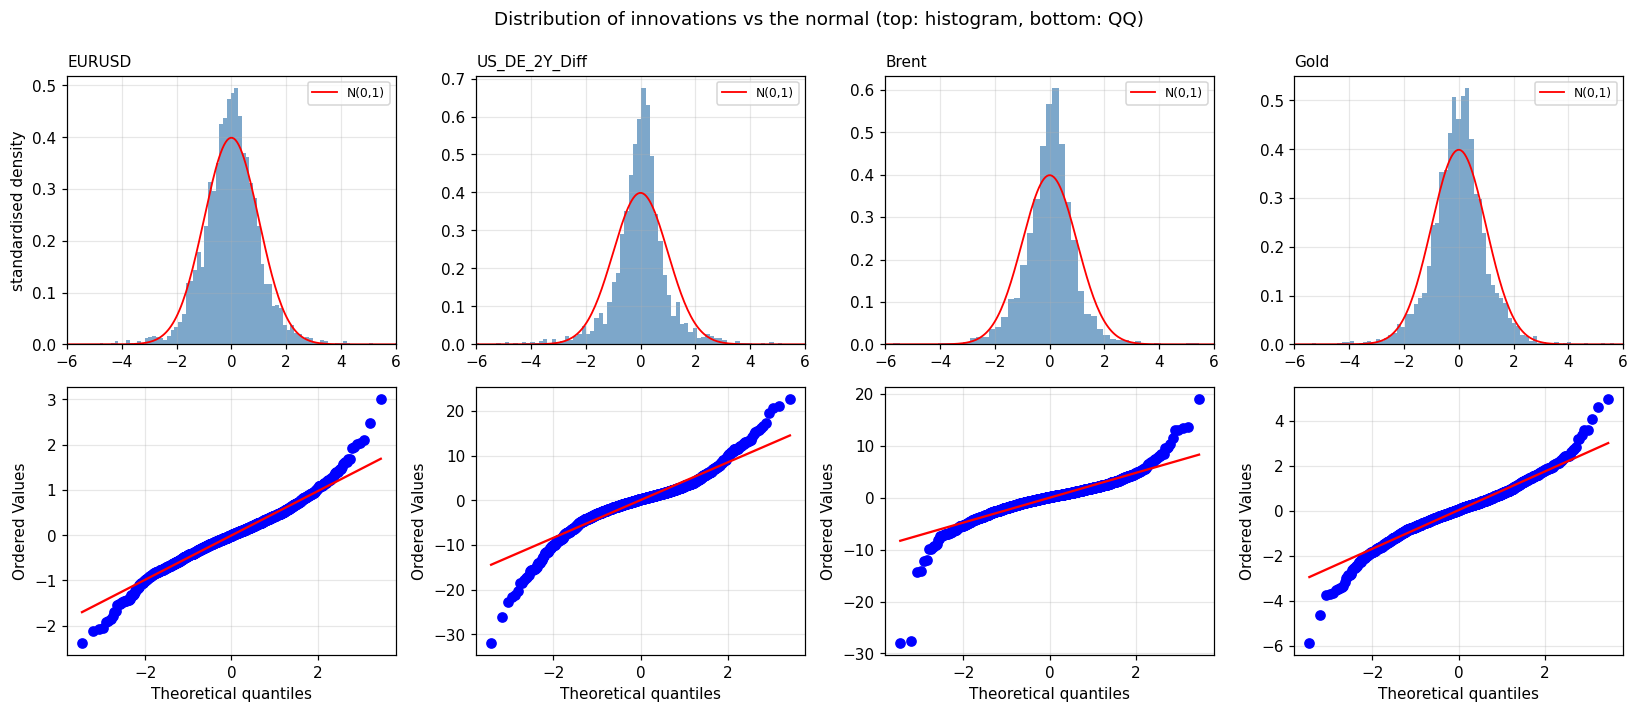

In [41]:
# Histogram + QQ plot for one representative series per asset class.
rep_for_dist = ["EURUSD", "US_DE_2Y_Diff", "Brent", "Gold"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for j, name in enumerate(rep_for_dist):
    s = wide[innovation[name]].dropna()
    z = (s - s.mean()) / s.std()
    axes[0, j].hist(z, bins=80, density=True, color="steelblue", alpha=0.7)
    x = np.linspace(-6, 6, 200)
    axes[0, j].plot(x, stats.norm.pdf(x), "r-", lw=1.2, label="N(0,1)")
    axes[0, j].set_title(name, loc="left", fontsize=10)
    axes[0, j].set_xlim(-6, 6); axes[0, j].legend(fontsize=8)
    stats.probplot(s, dist="norm", plot=axes[1, j])
    axes[1, j].set_title("")
axes[0, 0].set_ylabel("standardised density")
fig.suptitle("Distribution of innovations vs the normal (top: histogram, bottom: QQ)", y=0.99)
fig.tight_layout()
plt.show()

Excess kurtosis is positive for every series, confirming fat tails relative to the normal distribution, and the Jarque-Bera test rejects normality overwhelmingly across the board (p ≈ 0 for all but EURUSD, AUDUSD and USDCAD, which are still rejected at p < 1e-50). The magnitude varies sharply by asset class: FX is comparatively mild (EURUSD excess kurtosis 2.21, USDCAD 1.47), while rates and commodities are markedly heavier-tailed (DE2Y 18.86, US2Y 14.27, Brent 15.25). The QQ plots make the same point visually — points track the 45-degree line closely near the centre but diverge sharply in both tails, most severely for US_DE_2Y_Diff and Brent.

This confirms the Student-*t* innovation assumption used in the GARCH/EGARCH fits was the right choice over a Gaussian assumption. More importantly for the causality design: because the marginal distributions reject normality, the joint process cannot be Gaussian either (a Gaussian joint distribution requires Gaussian marginals). This means the exact equivalence between transfer entropy and linear Granger causality proved by Barnett, Barrett & Seth (2009) — which holds only for jointly Gaussian processes — cannot be assumed to hold here. That does not by itself guarantee transfer entropy will detect dependence that Granger causality misses; it only removes the theoretical guarantee that the two must agree. The comparison between them is therefore a genuine empirical question rather than a foregone conclusion, which is precisely what the formal analysis is designed to test.

## 3. Asymmetry 

This section re-examines, visually, the leverage asymmetry already quantified in notebook 01 via the EGARCH γ coefficient. Two views are used: a news-impact curve (today's conditional volatility against yesterday's signed shock) and a model-free comparison of next-day |innovation| following negative versus positive shocks.

**Important scope note.** This diagnostic answers a narrow question — *does allowing for asymmetry improve the fit of a single series' own volatility model* — and nothing more. It does **not** determine which proxy a series should contribute to the cross-market comparison. Using GARCH volatility for some series and EGARCH volatility for others in the same transfer-entropy or Granger-causality comparison would confound genuine transmission with differences in the underlying filter's dynamics: a detected asymmetry in the *relationship* between two markets could then simply be an artefact of comparing outputs from two structurally different models. To keep the cross-market comparison clean, the **primary analysis uses GARCH(1,1)-t conditional volatility uniformly across every series**, with absolute innovation and EGARCH volatility retained as uniform robustness alternatives (i.e. every series switched to the same proxy together, not a mix-and-match by asset class). The findings below inform the discussion of *why* asymmetry exists economically; they do not assign proxies.

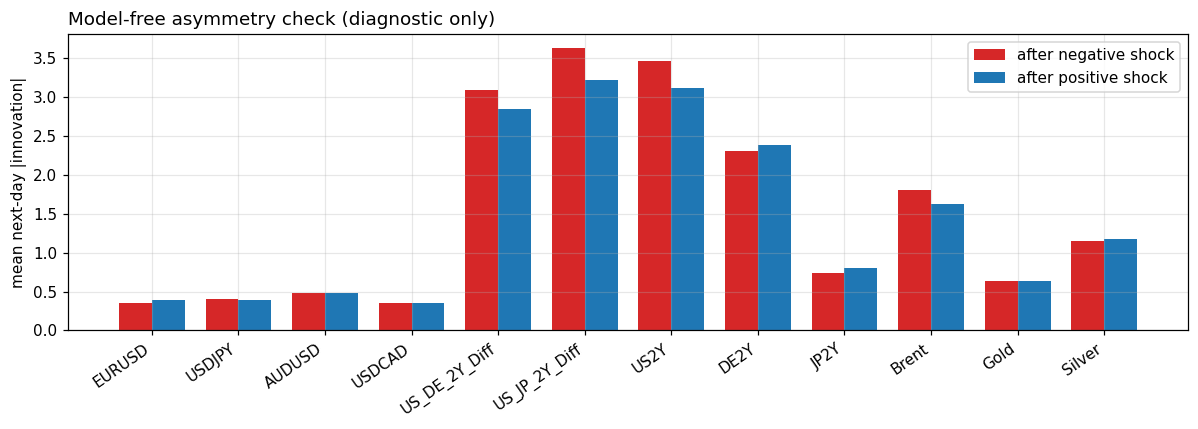

,after_negative,after_positive,diff (neg - pos)
series,,,
EURUSD,0.3487,0.3906,-0.0420
USDJPY,0.4090,0.3888,0.0201
AUDUSD,0.4774,0.4859,-0.0085
USDCAD,0.3465,0.3483,-0.0017
US_DE_2Y_Diff,3.0926,2.8531,0.2395
US_JP_2Y_Diff,3.6290,3.2248,0.4042
US2Y,3.4653,3.1156,0.3497
DE2Y,2.3038,2.3906,-0.0868
JP2Y,0.7433,0.8007,-0.0574


In [42]:
# Model-free view: mean next-day |innovation| following a negative vs positive shock.
rows = []
for name, col in innovation.items():
    s = wide[col].dropna()
    nxt = s.abs().shift(-1)
    rows.append({"series": name, "after_negative": nxt[s < 0].mean(),
                 "after_positive": nxt[s > 0].mean()})
asym = pd.DataFrame(rows).set_index("series")
asym["diff (neg - pos)"] = asym["after_negative"] - asym["after_positive"]

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(asym)); w = 0.38
ax.bar(x - w/2, asym["after_negative"], w, label="after negative shock", color="C3")
ax.bar(x + w/2, asym["after_positive"], w, label="after positive shock", color="C0")
ax.set_xticks(x); ax.set_xticklabels(asym.index, rotation=35, ha="right")
ax.set_ylabel("mean next-day |innovation|")
ax.set_title("Model-free asymmetry check (diagnostic only)", loc="left")
ax.legend(); fig.tight_layout(); plt.show()
asym.round(4)

The pattern here does not split cleanly along asset class. The four FX pairs all show small absolute differences (0.002–0.042), so asymmetry is genuinely weak for FX at daily frequency. Within the rates block, however, the picture is mixed: US_DE_2Y_Diff, US_JP_2Y_Diff and US2Y show some of the *largest* gaps in the whole table (0.24–0.40, exceeding Brent), while DE2Y and JP2Y are comparatively flat (0.06–0.09). Within commodities, Brent stands out with a sizeable positive difference (negative shocks followed by larger next-day moves), while Gold is essentially flat (diff ≈ 0.0001) and Silver is small and, notably, opposite in sign to Brent (its positive-shock days are followed by marginally larger moves, not its negative-shock days). This simple, model-free comparison is retained only to document that next-day asymmetry is real and heterogeneous across series — it does not feed into any proxy choice. The primary analysis uses GARCH(1,1)-t conditional volatility uniformly across every series regardless of this finding, for the reasons given above.

## 4. Stationarity

Both transfer entropy and Granger causality assume stationary inputs; a non-stationary input risks spurious detected dependence. Three representations of each series are tested, because they are not expected to behave the same way: the **raw innovation** (return or yield change), the **GARCH conditional volatility level**, and the **change in log conditional volatility**, $\Delta\log\hat\sigma_t$. The level is a smoothed, highly persistent recursive estimate rather than a directly observed series, so testing it is a useful diagnostic but not, by itself, decisive evidence about the stationarity of the underlying volatility process.

Two tests are run side by side, with opposite null hypotheses, since they can disagree and where they do the disagreement is itself informative: **ADF** (null: unit root / non-stationary) and **KPSS** (null: stationary).

In [43]:
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

def stationarity_battery(s):
    s = s.dropna()
    return {
        "ADF_p": adfuller(s, autolag="AIC")[1],
        "KPSS_p": kpss(s, regression="c", nlags="auto")[1],
    }

rows = []
for name, col in innovation.items():
    raw_res = stationarity_battery(wide[col])
    lvl_res = stationarity_battery(wide[f"{name}_garchvol"])
    dlogvol_res = stationarity_battery(np.log(wide[f"{name}_garchvol"]).diff())
    rows.append({
        "series": name,
        "raw_ADF": raw_res["ADF_p"], "raw_KPSS": raw_res["KPSS_p"],
        "level_ADF": lvl_res["ADF_p"], "level_KPSS": lvl_res["KPSS_p"],
        "dlogvol_ADF": dlogvol_res["ADF_p"], "dlogvol_KPSS": dlogvol_res["KPSS_p"],
    })

stationarity_table = pd.DataFrame(rows).set_index("series")
stationarity_table.round(3)

,raw_ADF,raw_KPSS,level_ADF,level_KPSS,dlogvol_ADF,dlogvol_KPSS
series,,,,,,
EURUSD,0.0,0.100,0.015,0.010,0.0,0.1
USDJPY,0.0,0.096,0.000,0.022,0.0,0.1
AUDUSD,0.0,0.100,0.007,0.059,0.0,0.1
USDCAD,0.0,0.100,0.020,0.010,0.0,0.1
US_DE_2Y_Diff,0.0,0.100,0.025,0.010,0.0,0.1
US_JP_2Y_Diff,0.0,0.100,0.014,0.010,0.0,0.1
US2Y,0.0,0.100,0.042,0.010,0.0,0.1
DE2Y,0.0,0.088,0.007,0.010,0.0,0.1
JP2Y,0.0,0.013,0.000,0.100,0.0,0.1


The raw innovations are stationary on both tests for 11 of the 12 series; the one exception is JP2Y, where KPSS rejects stationarity (p = 0.013) despite ADF rejecting a unit root. This is consistent with the extended flat-yield episodes under BoJ yield-curve control documented earlier in the data cleaning — a structural, policy-driven feature of that specific series rather than a general problem with the raw-innovation representation.

The conditional-volatility **level** is where most of the disagreement concentrates: 9 of the 12 series show ADF rejecting a unit root while KPSS simultaneously rejects stationarity. Three series are the exception and agree on stationarity at the level as well — AUDUSD, JP2Y and Brent. The change in log volatility, $\Delta\log\hat\sigma_t$, is again unambiguous: all 12 series pass both tests.

This pattern — conflict concentrated in the level, resolved entirely once the series is transformed to $\Delta\log\hat\sigma_t$ — is consistent with, rather than proof of, an explanation grounded in the GARCH fits themselves. The estimated persistence $(\alpha+\beta)$ is close to unity for almost every series in notebook 01 and effectively reaches one for the rate series, indicating extremely persistent conditional volatility with shocks decaying only slowly. Such near-IGARCH behaviour is a well-known source of exactly this kind of ADF/KPSS disagreement in financial volatility, and provides a plausible explanation for the conflict observed here — it is not treated as definitive proof, since the conditional-volatility level is itself a smoothed, model-implied series rather than a directly observed one, and the fact that removing persistence (via $\Delta\log\hat\sigma_t$) removes the conflict is only indirect support for this account.

The practical implication is carried forward rather than resolved here: the primary causality analysis uses the volatility **level** (its economic interpretation is direct), with $\Delta\log\hat\sigma_t$ retained as a robustness input specifically to check whether any detected transmission survives once the shared, slowly-decaying persistence common to near-integrated volatility processes is removed. If a result is significant on the level but disappears on the de-persisted series, that will be reported honestly as reflecting shared long-run volatility state rather than short-horizon shock transmission.

## 5. Persistence and long memory

Three complementary pieces of evidence for the same underlying property — that volatility dependence decays slowly over many days rather than dying out within one or two — are brought together here: the autocorrelation function of the innovations (and the Taylor effect within it), a formal Ljung-Box test on the absolute innovation at a longer lag than the ARCH-effect test in notebook 01 used, and the GARCH-implied half-life of a volatility shock. This evidence is what grounds daily-frequency sampling as adequate for studying volatility transmission: the property under study is not a high-frequency phenomenon that daily data would average away.

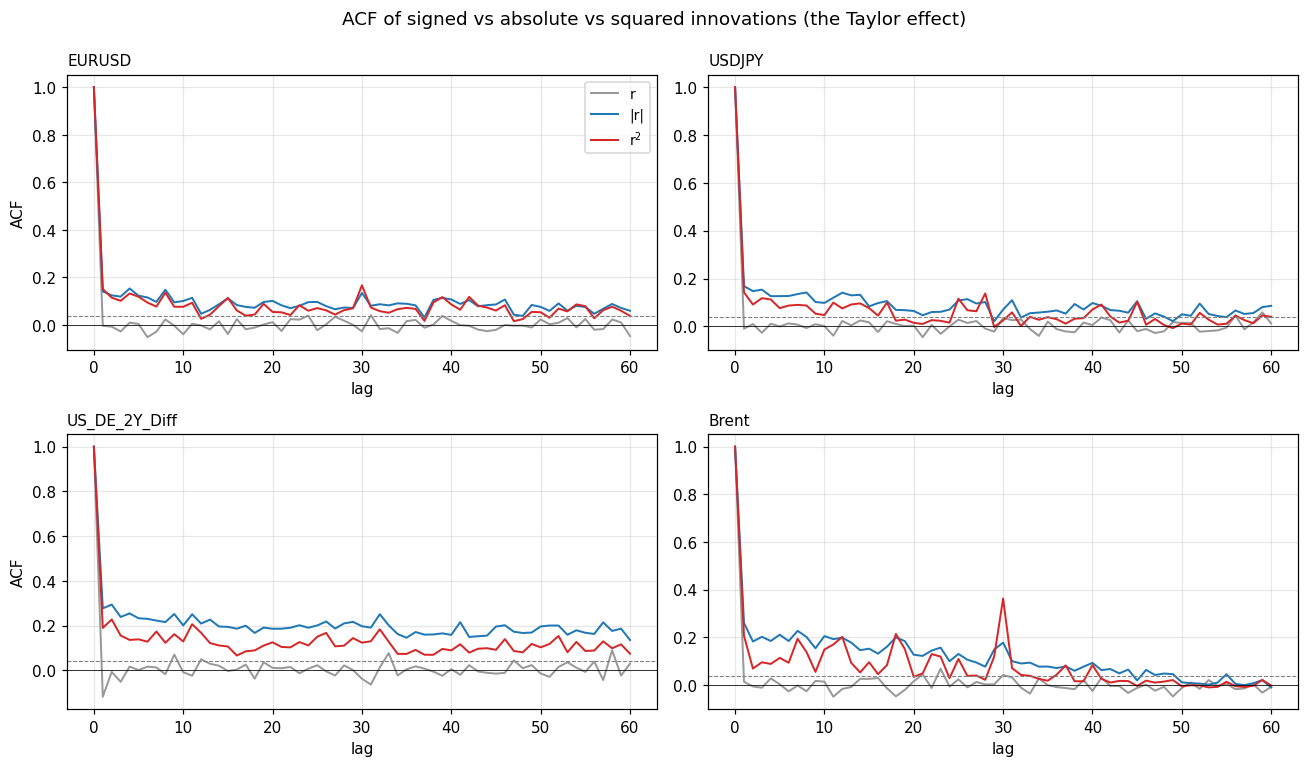

In [44]:
def acf_panel(name, ax, nlags=60):
    r = wide[innovation[name]].dropna().values
    for lab, x, col in [("r", r, "0.6"), ("|r|", np.abs(r), "C0"), ("r$^2$", r**2, "C3")]:
        a = acf(x, nlags=nlags, fft=True)
        ax.plot(range(nlags + 1), a, label=lab, color=col, lw=1.3)
    ci = 1.96 / np.sqrt(len(r))
    ax.axhline(ci, ls="--", color="grey", lw=0.7); ax.axhline(0, color="k", lw=0.5)
    ax.set_title(name, loc="left", fontsize=10); ax.set_xlabel("lag")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, name in zip(axes.ravel(), ["EURUSD", "USDJPY", "US_DE_2Y_Diff", "Brent"]):
    acf_panel(name, ax)
axes[0, 0].set_ylabel("ACF"); axes[1, 0].set_ylabel("ACF")
axes[0, 0].legend(loc="upper right", fontsize=9)
fig.suptitle("ACF of signed vs absolute vs squared innovations (the Taylor effect)", y=0.99)
fig.tight_layout(); plt.show()

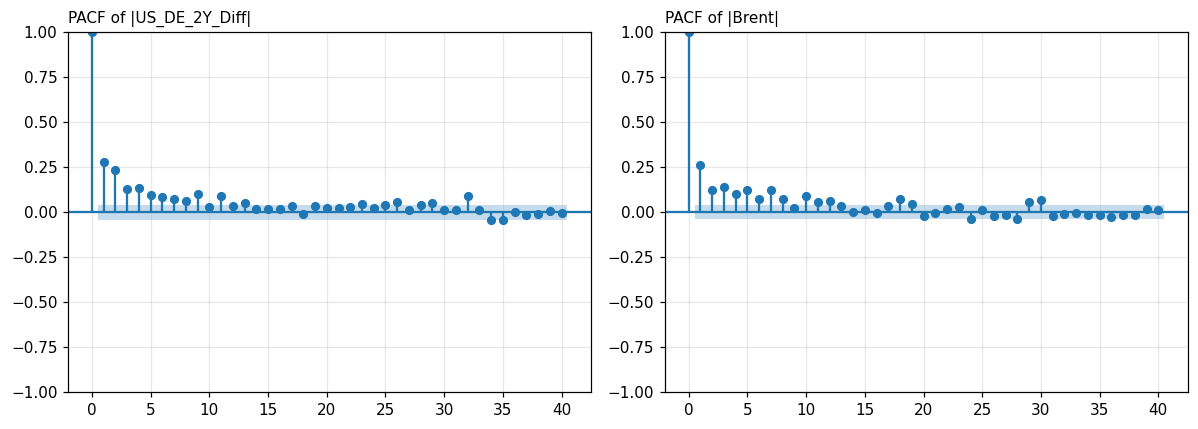

In [45]:
# PACF of the absolute innovation, to see how much of the slow decay is captured
# by a handful of lags versus persisting well beyond them.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, ["US_DE_2Y_Diff", "Brent"]):
    plot_pacf(wide[innovation[name]].dropna().abs(), lags=40, ax=ax, method="ywm", title="")
    ax.set_title(f"PACF of |{name}|", loc="left", fontsize=10)
fig.tight_layout(); plt.show()

In [46]:
rows = []
for name, col in innovation.items():
    r = wide[col].dropna().values
    a_abs = acf(np.abs(r), nlags=60, fft=True)
    lb = acorr_ljungbox(np.abs(r), lags=[20], return_df=True)
    ab = model_summary.loc[name, "persistence"]  # GARCH alpha+beta
    half_life = np.log(0.5) / np.log(ab) if ab < 1 else np.inf
    rows.append({
        "series": name,
        "ACF|r|_L1": a_abs[1], "ACF|r|_L20": a_abs[20], "ACF|r|_L60": a_abs[60],
        "LjungBox(20)_p": lb["lb_pvalue"].iloc[0],
        "GARCH_persistence (a+b)": ab,
        "half_life_days": half_life,
    })
persistence_table = pd.DataFrame(rows).set_index("series")
persistence_display = persistence_table.copy()
persistence_display["LjungBox(20)_p"] = persistence_display["LjungBox(20)_p"].map(lambda p: f"{p:.1e}")
persistence_display.round(3)

,ACF|r|_L1,ACF|r|_L20,ACF|r|_L60,LjungBox(20)_p,GARCH_persistence (a+b),half_life_days
series,,,,,,
EURUSD,0.141,0.102,0.060,1.3e-114,0.994,1.127600e+02
USDJPY,0.168,0.064,0.086,9.1e-147,0.984,4.254300e+01
AUDUSD,0.059,0.093,0.029,2.5e-59,0.993,1.023510e+02
USDCAD,0.133,0.095,0.056,6.3e-88,0.995,1.525010e+02
US_DE_2Y_Diff,0.277,0.186,0.136,0.0e+00,1.000,inf
US_JP_2Y_Diff,0.355,0.223,0.208,0.0e+00,1.000,8.361336e+07
US2Y,0.373,0.246,0.208,0.0e+00,1.000,inf
DE2Y,0.448,0.323,0.375,0.0e+00,1.000,inf
JP2Y,0.294,0.115,0.050,6.8e-234,1.000,inf


Every series rejects the Ljung-Box null overwhelmingly at lag 20, confirming clustering persists well beyond the handful of lags a simple ARCH-effect test would check. The half-life column translates the GARCH persistence into an interpretable horizon: FX shocks take roughly 40–150 days to decay by half, commodities 35–125 days, and the rate differentials and individual yields have a half-life that is effectively infinite given $(\alpha+\beta)$ at or indistinguishable from one. Whatever the precise number, all of these are multi-week to multi-month horizons — orders of magnitude longer than the intraday window over which return-level price discovery is thought to complete. This is the concrete quantitative form of the argument that daily sampling is adequate here: the object under study operates on a timescale daily data can resolve.

## 6. Contemporaneous correlation

In [47]:
corr_pairs = [("US_DE_2Y_Diff", "EURUSD"), ("US_JP_2Y_Diff", "USDJPY"),
              ("Brent", "USDCAD"), ("Gold", "AUDUSD"), ("Silver", "AUDUSD")]

rows = []
for src, fx in corr_pairs:
    sub = wide[[f"{src}_garchvol", f"{fx}_garchvol"]].dropna()
    rows.append({"source": src, "FX": fx, "same_day_corr": sub.corr().iloc[0, 1]})
same_day = pd.DataFrame(rows)
same_day.round(3)

,source,FX,same_day_corr
0,US_DE_2Y_Diff,EURUSD,0.302
1,US_JP_2Y_Diff,USDJPY,0.483
2,Brent,USDCAD,0.492
3,Gold,AUDUSD,0.531
4,Silver,AUDUSD,0.422


Same-day correlation of the GARCH conditional volatilities is substantial across every primary channel (0.30–0.53), confirming what the time-series overlay in Section 1 suggested visually. This matters for what comes next: a linear correlation this large, occurring on the same day, cannot on its own say which market moves first — it is equally consistent with simultaneous reaction to shared news, one market truly leading, or a common underlying driver moving both. Section 7 looks for structure beyond lag zero; a formal answer to direction requires the causality methods in the next notebook.

## 7. Preliminary Cross-Market Dependence

Raw lead–lag patterns are largely explained by the strong persistence inherent in volatility processes. This motivates the use of conditional directional dependence measures—linear Granger causality, parametric EGARCH spillover models, and nonparametric Transfer Entropy—to identify genuine cross-market volatility transmission.

Cross-correlation provides a descriptive view of the temporal association between volatility processes but does not establish directional transmission. Since financial volatility is highly persistent, raw cross-correlations may largely reflect autocorrelation rather than genuine cross-market spillovers. This section therefore first explores the empirical delay structure using volatility shocks and then examines how the observed patterns change after removing persistence. The objective is not to infer causality, but to identify the time scale over which cross-market dependence is most evident and to motivate the conditional models employed in the following sections.

### 7.1 Delay Structure Using Volatility Shocks

To characterise the empirical timing of cross-market dependence, cross-correlations are computed using daily volatility shocks rather than volatility levels.

Volatility shocks are defined as

$$
\Delta \log(\sigma_t)
=
\log(\sigma_t)-\log(\sigma_{t-1}),
$$

where $\sigma_t$ denotes the volatility proxy on trading day $t$. This transformation measures the daily proportional change in volatility and substantially reduces the persistence present in volatility levels.

Compared with raw volatility levels, $\Delta\log(\sigma_t)$ provides a cleaner description of short-run volatility changes and the empirical delay structure between markets. However, it should be interpreted as a volatility change rather than a fully model-based innovation.

Cross-correlations are computed over lags from $-10$ to $+10$ trading days. The cross-correlation function is defined as

$$
\operatorname{CCF}_{S,F}(k)
=
\operatorname{Corr}
\left(
\Delta\log(\sigma^{S}_t),
\Delta\log(\sigma^{F}_{t+k})
\right),
$$

where $S$ denotes the source market and $F$ denotes the FX market.

Under this convention:

- $k>0$: the source-market volatility shock at day $t$ is correlated with the FX volatility shock $k$ trading days later; this is the source-leading side;
- $k=0$: the volatility shocks are contemporaneously correlated;
- $k<0$: the FX volatility shock occurs earlier; this is the FX-leading side.

For each asset pair, the analysis examines:

- the lag at which the maximum absolute correlation occurs;
- the magnitude and sign of the peak correlation;
- whether the peak lies on the source-leading or FX-leading side;
- how rapidly the correlation decays away from the peak.



In [58]:
# Daily changes in log GARCH conditional volatility.
# These columns measure short-run proportional changes in volatility.

for name in innovation:
    vol = pd.to_numeric(
        wide[f"{name}_garchvol"],
        errors="coerce"
    )

    # Conditional volatility should be strictly positive before taking logs.
    vol = vol.where(vol > 0)

    wide[f"{name}_dlogvol"] = np.log(vol).diff()

In [59]:
def xcorr(source, fx, maxlag=10):
    """
    Compute CCF(k) = Corr(Source_t, FX_{t+k}).

    Lag convention
    --------------
    k > 0 : source leads FX by k trading days
    k = 0 : contemporaneous association
    k < 0 : FX leads source by |k| trading days
    """

    data = pd.concat(
        [
            pd.Series(source, name="source"),
            pd.Series(fx, name="fx")
        ],
        axis=1
    ).dropna()

    source_aligned = data["source"]
    fx_aligned = data["fx"]

    correlations = []

    for k in range(-maxlag, maxlag + 1):

        # Corr(Source_t, FX_{t+k})
        shifted_fx = fx_aligned.shift(-k)

        pair = pd.concat(
            [source_aligned, shifted_fx],
            axis=1
        ).dropna()

        correlations.append(
            pair.iloc[:, 0].corr(pair.iloc[:, 1])
        )

    return (
        np.arange(-maxlag, maxlag + 1),
        np.asarray(correlations)
    )

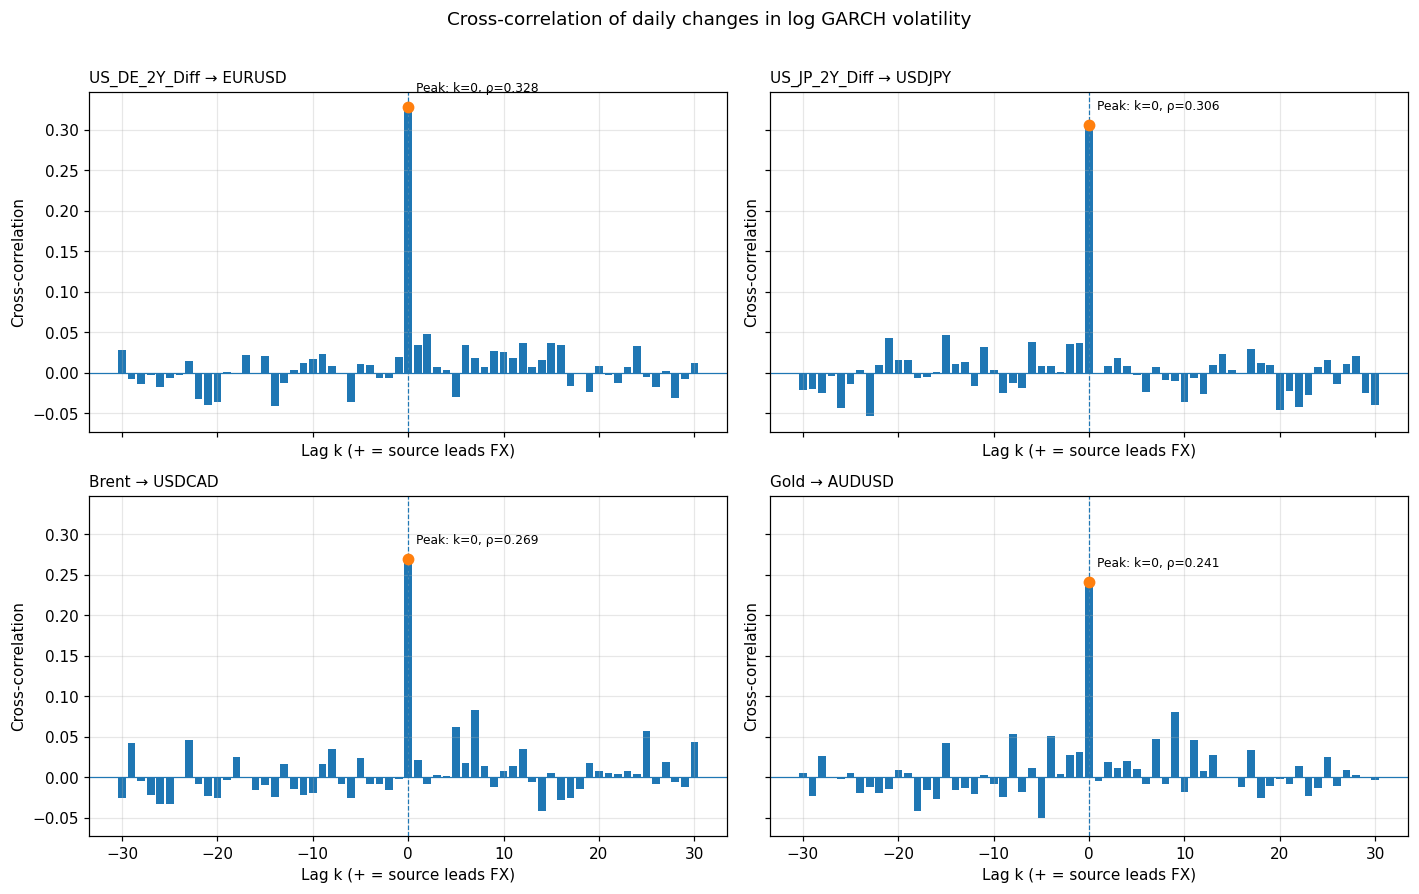

,source,FX,peak_lag,peak_correlation,absolute_peak,peak_side,n_observations
0,US_DE_2Y_Diff,EURUSD,0,0.328,0.328,Contemporaneous,2168
1,US_JP_2Y_Diff,USDJPY,0,0.306,0.306,Contemporaneous,2009
2,Brent,USDCAD,0,0.269,0.269,Contemporaneous,2567
3,Gold,AUDUSD,0,0.241,0.241,Contemporaneous,2581


In [61]:
maxlag = 30

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8),
    sharex=True,
    sharey=True
)

shock_summary_rows = []

for ax, (src, fx) in zip(axes.ravel(), channel_pairs):

    sub = wide[
        [
            f"{src}_dlogvol",
            f"{fx}_dlogvol"
        ]
    ].dropna()

    source_change = sub[f"{src}_dlogvol"]
    fx_change = sub[f"{fx}_dlogvol"]

    lags, cc = xcorr(
        source_change,
        fx_change,
        maxlag=maxlag
    )

    peak_position = np.nanargmax(np.abs(cc))
    peak_lag = int(lags[peak_position])
    peak_corr = float(cc[peak_position])

    ax.bar(lags, cc)
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linestyle="--", linewidth=0.8)

    ax.scatter(
        peak_lag,
        peak_corr,
        s=45,
        zorder=3
    )

    ax.annotate(
        f"Peak: k={peak_lag}, ρ={peak_corr:.3f}",
        xy=(peak_lag, peak_corr),
        xytext=(5, 10),
        textcoords="offset points",
        fontsize=8
    )

    ax.set_title(
        f"{src} → {fx}",
        loc="left",
        fontsize=10
    )

    ax.set_xlabel("Lag k (+ = source leads FX)")
    ax.set_ylabel("Cross-correlation")

    if peak_lag > 0:
        peak_side = "Source-leading"
    elif peak_lag < 0:
        peak_side = "FX-leading"
    else:
        peak_side = "Contemporaneous"

    shock_summary_rows.append(
        {
            "source": src,
            "FX": fx,
            "peak_lag": peak_lag,
            "peak_correlation": peak_corr,
            "absolute_peak": abs(peak_corr),
            "peak_side": peak_side,
            "n_observations": len(sub)
        }
    )

fig.suptitle(
    "Cross-correlation of daily changes in log GARCH volatility",
    y=1.01
)

fig.tight_layout()
plt.show()

shock_delay_summary = pd.DataFrame(shock_summary_rows)

shock_delay_summary.round(
    {
        "peak_correlation": 3,
        "absolute_peak": 3
    }
)

Across all four source–FX pairs, the largest absolute cross-correlation in daily changes in log conditional volatility occurs at lag zero. The contemporaneous correlations range from 0.241 for Gold–AUDUSD to 0.328 for the US–Germany two-year yield differential and EURUSD.

Correlations at non-zero lags are considerably smaller and do not exhibit a stable monotonic decay from a delayed peak. The dependence in volatility changes is therefore concentrated primarily within the same trading day rather than at a clearly defined multi-day source-leading horizon.

This result does not imply the absence of volatility transmission. At daily frequency, information transmitted within the trading day is recorded as contemporaneous dependence. In addition, unconditional cross-correlation may fail to reveal incremental directional information that becomes apparent only after conditioning on each market's own history.

### 7.2 Sensitivity to Volatility Persistence

To assess how much of the observed delay structure is attributable to volatility persistence, the cross-correlation analysis is repeated using raw GARCH conditional volatility levels.

The comparison focuses on two quantities:

1. whether the location of the peak cross-correlation changes after transforming volatility levels into daily log changes; and
2. how much the magnitude of the peak cross-correlation declines.

A substantial reduction in correlation magnitude would indicate that the broad cross-lag dependence in volatility levels is driven materially by their persistent dynamics.

A stable non-zero peak after transformation would provide descriptive motivation for subsequent directional analysis, but it would still not establish genuine transmission.

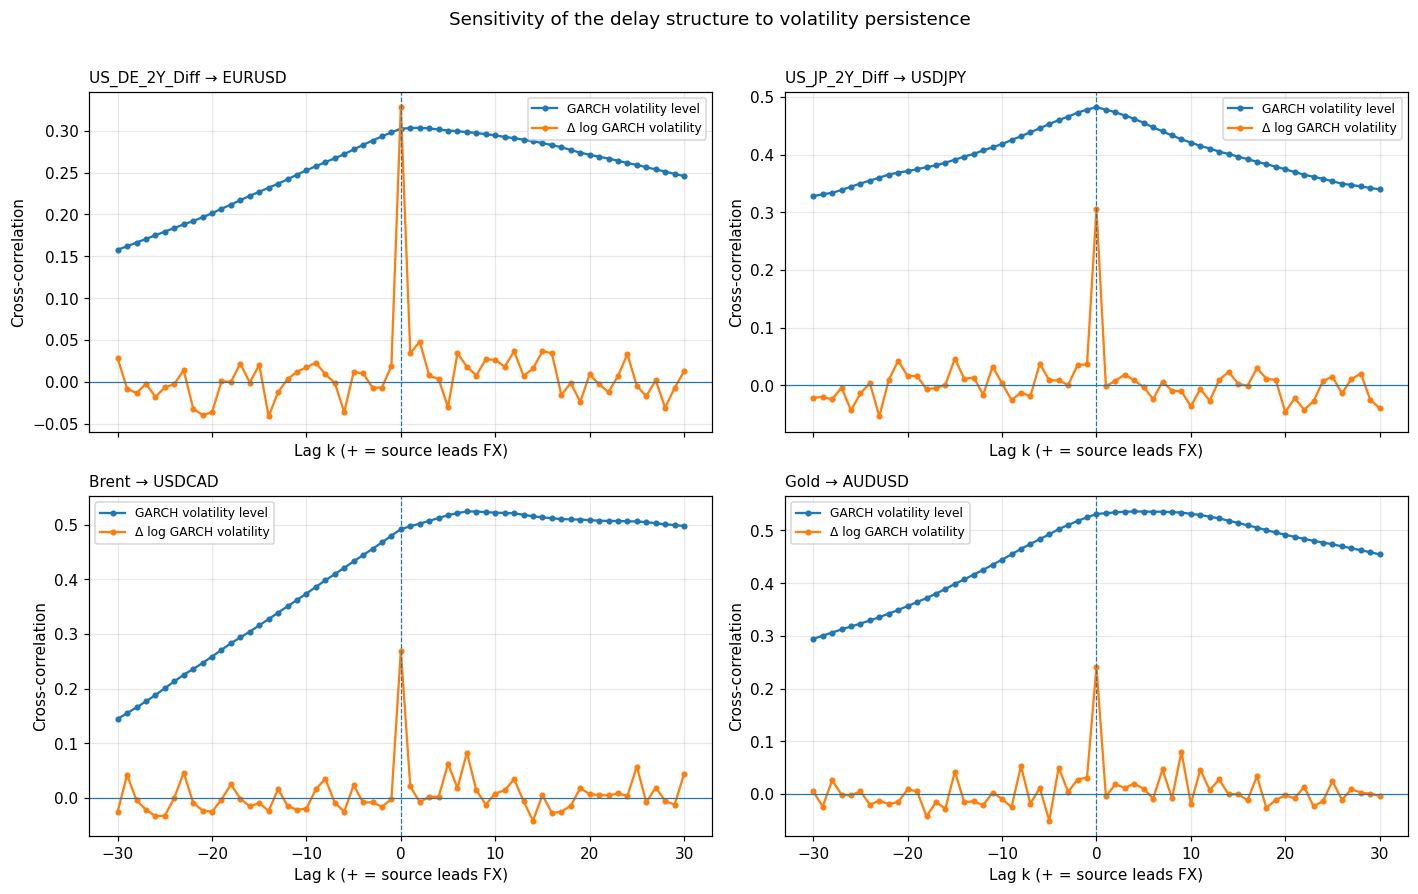

,source,FX,level_peak_lag,level_peak_corr,dlogvol_peak_lag,dlogvol_peak_corr,peak_lag_shift,absolute_peak_reduction_pct
0,US_DE_2Y_Diff,EURUSD,2,0.303,0,0.328,-2,-8.1
1,US_JP_2Y_Diff,USDJPY,0,0.483,0,0.306,0,36.6
2,Brent,USDCAD,7,0.524,0,0.269,-7,48.6
3,Gold,AUDUSD,4,0.536,0,0.241,-4,55.0


In [65]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8),
    sharex=True
)

comparison_rows = []

for ax, (src, fx) in zip(axes.ravel(), channel_pairs):

    level_sub = wide[
        [
            f"{src}_garchvol",
            f"{fx}_garchvol"
        ]
    ].dropna()

    change_sub = wide[
        [
            f"{src}_dlogvol",
            f"{fx}_dlogvol"
        ]
    ].dropna()

    level_lags, level_cc = xcorr(
        level_sub[f"{src}_garchvol"],
        level_sub[f"{fx}_garchvol"],
        maxlag=maxlag
    )

    change_lags, change_cc = xcorr(
        change_sub[f"{src}_dlogvol"],
        change_sub[f"{fx}_dlogvol"],
        maxlag=maxlag
    )

    ax.plot(
        level_lags,
        level_cc,
        marker="o",
        markersize=3,
        label="GARCH volatility level"
    )

    ax.plot(
        change_lags,
        change_cc,
        marker="o",
        markersize=3,
        label="Δ log GARCH volatility"
    )

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linestyle="--", linewidth=0.8)

    ax.set_title(
        f"{src} → {fx}",
        loc="left",
        fontsize=10
    )

    ax.set_xlabel("Lag k (+ = source leads FX)")
    ax.set_ylabel("Cross-correlation")
    ax.legend(fontsize=8)

    level_peak_position = np.nanargmax(np.abs(level_cc))
    change_peak_position = np.nanargmax(np.abs(change_cc))

    level_peak_lag = int(level_lags[level_peak_position])
    change_peak_lag = int(change_lags[change_peak_position])

    level_peak = float(level_cc[level_peak_position])
    change_peak = float(change_cc[change_peak_position])

    if abs(level_peak) > 0:
        peak_reduction = (
            1 - abs(change_peak) / abs(level_peak)
        ) * 100
    else:
        peak_reduction = np.nan

    comparison_rows.append(
        {
            "source": src,
            "FX": fx,
            "level_peak_lag": level_peak_lag,
            "level_peak_corr": level_peak,
            "dlogvol_peak_lag": change_peak_lag,
            "dlogvol_peak_corr": change_peak,
            "peak_lag_shift": change_peak_lag - level_peak_lag,
            "absolute_peak_reduction_pct": peak_reduction
        }
    )

fig.suptitle(
    "Sensitivity of the delay structure to volatility persistence",
    y=1.01
)


plt.savefig(
    "../figures/ccf_level_vs_shock.png",
    dpi=300,
    bbox_inches="tight"
)

fig.tight_layout()
plt.show()

persistence_comparison = pd.DataFrame(comparison_rows)

persistence_comparison.round(
    {
        "level_peak_corr": 3,
        "dlogvol_peak_corr": 3,
        "absolute_peak_reduction_pct": 1
    }
)

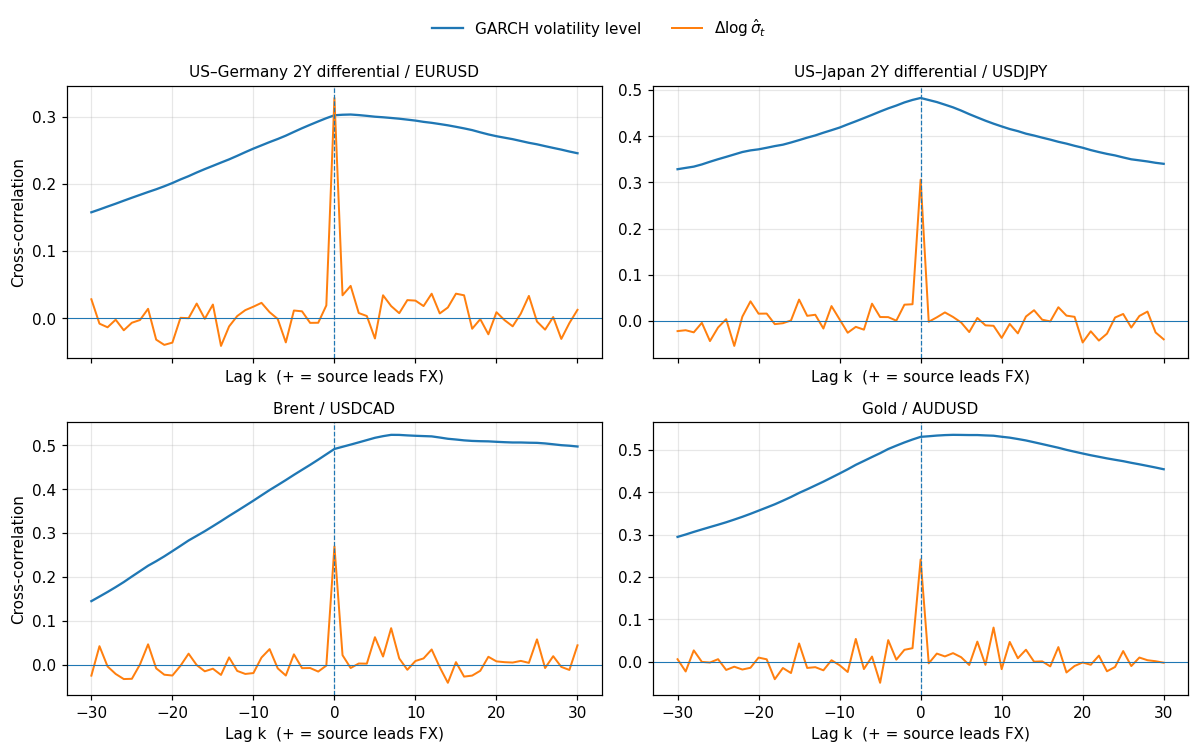

Saved PNG: /Users/nancyshi/Desktop/2026 summer project/Volatility_Project/figures/figure_6_1_ccf_persistence_sensitivity.png
Saved PDF: /Users/nancyshi/Desktop/2026 summer project/Volatility_Project/figures/figure_6_1_ccf_persistence_sensitivity.pdf


In [66]:
# ============================================================
# Dissertation Figure 6.1
# Persistence sensitivity of cross-correlation structure
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt

DISS_FIG_DIR = FIGURES_DIR
DISS_FIG_DIR.mkdir(parents=True, exist_ok=True)

channel_labels = {
    ("US_DE_2Y_Diff", "EURUSD"):
        "US–Germany 2Y differential / EURUSD",
    ("US_JP_2Y_Diff", "USDJPY"):
        "US–Japan 2Y differential / USDJPY",
    ("Brent", "USDCAD"):
        "Brent / USDCAD",
    ("Gold", "AUDUSD"):
        "Gold / AUDUSD",
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 6.8),
    sharex=True
)

for ax, (src, fx) in zip(axes.ravel(), channel_pairs):

    level_sub = wide[
        [f"{src}_garchvol", f"{fx}_garchvol"]
    ].dropna()

    shock_sub = wide[
        [f"{src}_dlogvol", f"{fx}_dlogvol"]
    ].dropna()

    level_lags, level_cc = xcorr(
        level_sub[f"{src}_garchvol"],
        level_sub[f"{fx}_garchvol"],
        maxlag=30
    )

    shock_lags, shock_cc = xcorr(
        shock_sub[f"{src}_dlogvol"],
        shock_sub[f"{fx}_dlogvol"],
        maxlag=30
    )

    ax.plot(
        level_lags,
        level_cc,
        linewidth=1.5,
        label="GARCH volatility level"
    )

    ax.plot(
        shock_lags,
        shock_cc,
        linewidth=1.3,
        label=r"$\Delta\log\hat{\sigma}_t$"
    )

    ax.axhline(
        0,
        linewidth=0.7
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=0.8
    )

    ax.set_title(
        channel_labels[(src, fx)],
        fontsize=10
    )

    ax.set_xlabel(
        "Lag k  (+ = source leads FX)"
    )

axes[0, 0].set_ylabel("Cross-correlation")
axes[1, 0].set_ylabel("Cross-correlation")

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

png_file = (
    DISS_FIG_DIR
    / "figure_6_1_ccf_persistence_sensitivity.png"
)

pdf_file = (
    DISS_FIG_DIR
    / "figure_6_1_ccf_persistence_sensitivity.pdf"
)

fig.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    pdf_file,
    bbox_inches="tight"
)

plt.show()

print(f"Saved PNG: {png_file}")
print(f"Saved PDF: {pdf_file}")

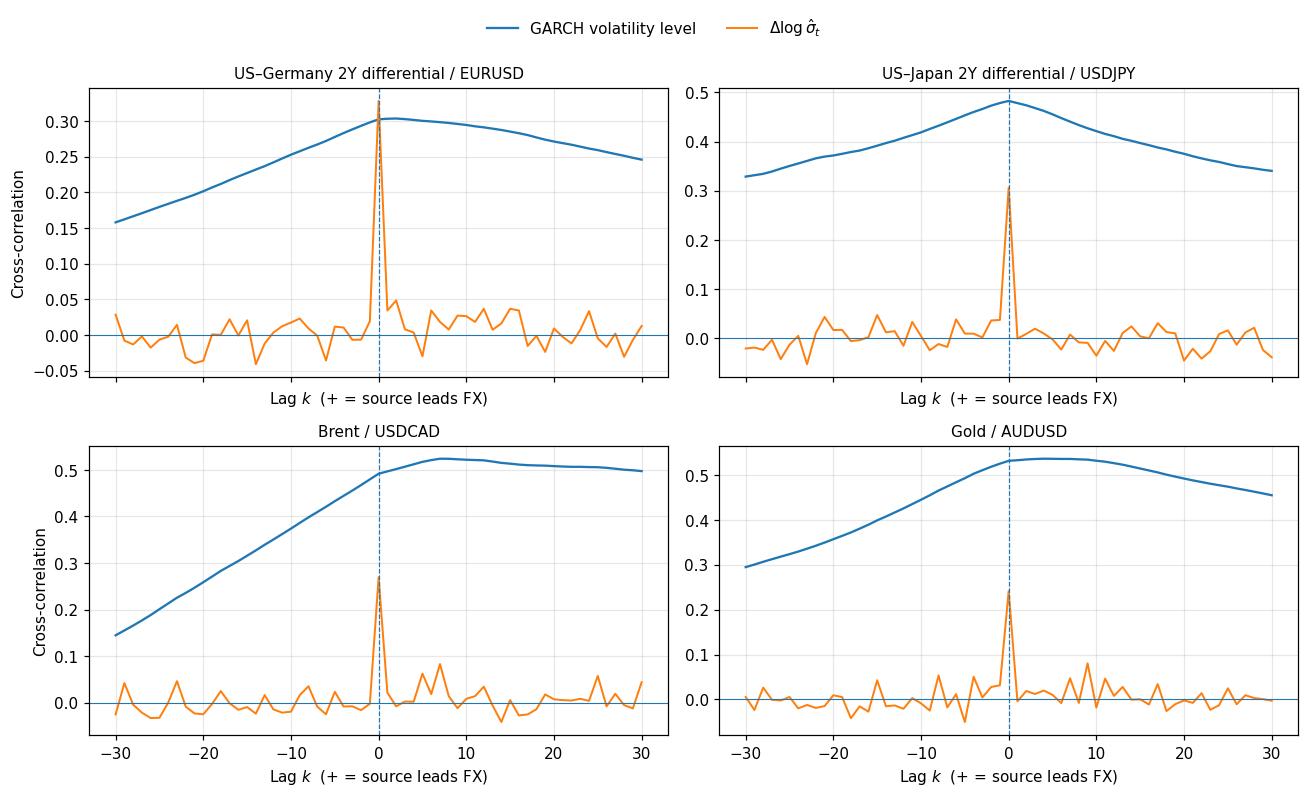

Saved: /Users/nancyshi/Desktop/2026 summer project/Volatility_Project/figures/figure_6_1_ccf_persistence.pdf
Saved: /Users/nancyshi/Desktop/2026 summer project/Volatility_Project/figures/figure_6_1_ccf_persistence.png


In [67]:
# ============================================================
# Dissertation Figure 6.1
# CCF sensitivity to volatility persistence
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 7.2),
    sharex=True
)

channel_titles = {
    ("US_DE_2Y_Diff", "EURUSD"):
        "US–Germany 2Y differential / EURUSD",
    ("US_JP_2Y_Diff", "USDJPY"):
        "US–Japan 2Y differential / USDJPY",
    ("Brent", "USDCAD"):
        "Brent / USDCAD",
    ("Gold", "AUDUSD"):
        "Gold / AUDUSD",
}

for ax, (src, fx) in zip(axes.ravel(), channel_pairs):

    # Conditional-volatility levels
    level_sub = wide[
        [f"{src}_garchvol", f"{fx}_garchvol"]
    ].dropna()

    level_lags, level_cc = xcorr(
        level_sub[f"{src}_garchvol"],
        level_sub[f"{fx}_garchvol"],
        maxlag=30
    )

    # Volatility shocks: Δ log sigma
    shock_sub = wide[
        [f"{src}_dlogvol", f"{fx}_dlogvol"]
    ].dropna()

    shock_lags, shock_cc = xcorr(
        shock_sub[f"{src}_dlogvol"],
        shock_sub[f"{fx}_dlogvol"],
        maxlag=30
    )

    ax.plot(
        level_lags,
        level_cc,
        linewidth=1.5,
        label="GARCH volatility level"
    )

    ax.plot(
        shock_lags,
        shock_cc,
        linewidth=1.3,
        label=r"$\Delta \log \hat{\sigma}_t$"
    )

    ax.axhline(0, linewidth=0.7)
    ax.axvline(0, linestyle="--", linewidth=0.8)

    ax.set_title(
        channel_titles[(src, fx)],
        fontsize=10
    )

    ax.set_xlabel(
        "Lag $k$  (+ = source leads FX)"
    )

axes[0, 0].set_ylabel("Cross-correlation")
axes[1, 0].set_ylabel("Cross-correlation")

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

pdf_path = FIGURES_DIR / "figure_6_1_ccf_persistence.pdf"
png_path = FIGURES_DIR / "figure_6_1_ccf_persistence.png"

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", pdf_path)
print("Saved:", png_path)

In [64]:
section7_summary = persistence_comparison[
    [
        "source",
        "FX",
        "level_peak_lag",
        "level_peak_corr",
        "dlogvol_peak_lag",
        "dlogvol_peak_corr",
        "peak_lag_shift",
        "absolute_peak_reduction_pct"
    ]
].copy()

section7_summary.columns = [
    "Source",
    "FX",
    "Raw-volatility peak lag",
    "Raw-volatility peak correlation",
    "Δlog-volatility peak lag",
    "Δlog-volatility peak correlation",
    "Peak-lag shift",
    "Peak-magnitude reduction (%)"
]

section7_summary.round(3)

,Source,FX,Raw-volatility peak lag,Raw-volatility peak correlation,Δlog-volatility peak lag,Δlog-volatility peak correlation,Peak-lag shift,Peak-magnitude reduction (%)
0,US_DE_2Y_Diff,EURUSD,2,0.303,0,0.328,-2,-8.121
1,US_JP_2Y_Diff,USDJPY,0,0.483,0,0.306,0,36.594
2,Brent,USDCAD,7,0.524,0,0.269,-7,48.571
3,Gold,AUDUSD,4,0.536,0,0.241,-4,54.955


The comparison with raw GARCH volatility levels demonstrates that persistence materially affects the apparent delay structure.

For Brent–USDCAD and Gold–AUDUSD, volatility levels produce broad source-leading peaks at seven and four trading days, respectively. After transforming the series into daily log-volatility changes, both peaks move to lag zero and their magnitudes decline by approximately 49% and 55%. The apparent delayed commodity–FX relationships in volatility levels are therefore not robust to the removal of persistence.

The US–Japan rate differential and USDJPY retain a lag-zero peak, although its magnitude declines by approximately 37%. For the US–Germany rate differential and EURUSD, the maximum correlation increases slightly after transformation, but the peak shifts from lag two to lag zero. This indicates that the short-run relationship is contemporaneous rather than a robust two-day source-leading effect.

Overall, the broad and asymmetric cross-correlation patterns observed in volatility levels are largely attributable to persistent and overlapping volatility episodes. Once persistence is reduced, cross-market dependence becomes sharply concentrated at the contemporaneous horizon.

### 7.3 Implications for Subsequent Directional Analysis

The cross-correlation results describe when cross-market volatility changes are most strongly associated. They do not determine why those associations arise.

Cross-correlations at non-zero lags may reflect:

- persistence within the source or FX volatility process;
- simultaneous exposure to common macroeconomic or financial shocks;
- differences in market closing times and information timing;
- genuine cross-market volatility transmission.

Even an asymmetric cross-correlation pattern is therefore insufficient to establish that one market transmits volatility to another.

The subsequent empirical analysis addresses this limitation using three complementary conditional methods:

1. **Linear Granger causality**, which tests whether lagged source-market volatility improves the linear prediction of FX volatility after conditioning on the FX market's own history;

2. **Parametric EGARCH spillover models**, which estimate cross-market volatility effects while explicitly modelling conditional heteroskedasticity and asymmetric volatility dynamics;

3. **Transfer Entropy**, which tests for nonlinear directional information transfer beyond the linear dependence captured by Granger causality.

These methods determine whether the descriptive delay patterns documented in this section correspond to incremental and directionally informative cross-market dependence.

## 7. Lead–lag structure

The cross-correlation function used throughout this section is defined as

$$\text{CCF}(k) = \text{Corr}(\text{Source}_t, \text{FX}_{t+k})$$

By this definition, $k > 0$ always means the source's value at time $t$ is being compared to FX's value $k$ days later — the source leads FX. $k < 0$ always means FX leads the source. This convention is fixed for every plot and every statistic in this section; no other sign convention is used anywhere below.

A lead–lag asymmetry in this CCF — one side of $k$ decaying slower or sitting higher than the other — does not by itself mean a volatility shock in one market transmits to the other. It can equally arise from any of the following, none of which involve genuine cross-market information flow:

- volatility clustering within each series individually;
- smoothing introduced by the GARCH filter itself;
- the two series simply having different own decay rates;
- a common shock (e.g. a global risk event) hitting both markets at the same time, which creates correlation at every lag without either market causing the other;
- misalignment from sample boundaries or missing dates.

What would actually demonstrate cross-asset volatility spillover is narrower and more specific: **that after controlling for FX's own history and for the source's own persistence, the source's past still explains something about FX's future volatility that FX's own past does not already explain.** That is the object this section works toward, in three steps — checking whether the raw asymmetry is even statistically meaningful (7.1), whether it survives once each series' own persistence is stripped out through several independent filtering methods (7.2), and whether what remains is distinguishable from a persistence-preserving null (7.3).

In [52]:
def xcorr(source, fx, maxlag=30):
    """CCF(k) = Corr(Source_t, FX_{t+k}). k > 0: source leads FX. k < 0: FX leads source."""
    a = (source - source.mean()) / source.std()
    b = (fx - fx.mean()) / fx.std()
    n = len(a)
    lags = list(range(-maxlag, maxlag + 1))
    out = []
    for k in lags:
        if k >= 0:
            out.append(np.corrcoef(a[:n - k], b[k:])[0, 1])
        else:
            j = -k
            out.append(np.corrcoef(a[j:], b[:n - j])[0, 1])
    return np.array(lags), np.array(out)

def asym_stat(source, fx, maxlag=30):
    """sum_{k=1..maxlag} [CCF(+k) - CCF(-k)]. Positive: source-leads-FX side is stronger."""
    lags, cc = xcorr(source, fx, maxlag)
    pos = cc[maxlag + 1:2 * maxlag + 1]
    neg = cc[0:maxlag][::-1]
    return (pos - neg).sum()

channel_pairs = [("US_DE_2Y_Diff", "EURUSD"), ("US_JP_2Y_Diff", "USDJPY"),
                  ("Brent", "USDCAD"), ("Gold", "AUDUSD")]


from arch import arch_model

def get_std_resid(series):
    s = series.dropna()
    res = arch_model(s, mean="Constant", vol="GARCH", p=1, q=1, dist="t", rescale=True).fit(disp="off")
    return pd.Series(res.std_resid, index=s.index)

for name, col in innovation.items():
    z = get_std_resid(wide[col])
    wide.loc[z.index, f"{name}_stdresid"] = z
    wide.loc[z.index, f"{name}_abs_stdresid"] = z.abs()
    wide.loc[z.index, f"{name}_sq_stdresid"] = z.pow(2)
    wide[f"{name}_dlogvol"] = np.log(wide[f"{name}_garchvol"]).diff()

### 7.1 Raw cross-correlation: naive vs Bartlett-corrected bands

The naive confidence band $1.96/\sqrt{n}$ assumes both input series are white noise. Given the persistence established in Section 5, that assumption fails here, so the band understates how much correlation could arise by chance from two autocorrelated series alone. The Bartlett correction (Box & Jenkins; Haugh 1976) accounts for this:

$$\text{SE}(\hat\rho_{xy}(k)) \approx \frac{1}{\sqrt{n}}\sqrt{\sum_{j=-\infty}^{\infty} \hat\rho_{xx}(j)\hat\rho_{yy}(j)}$$

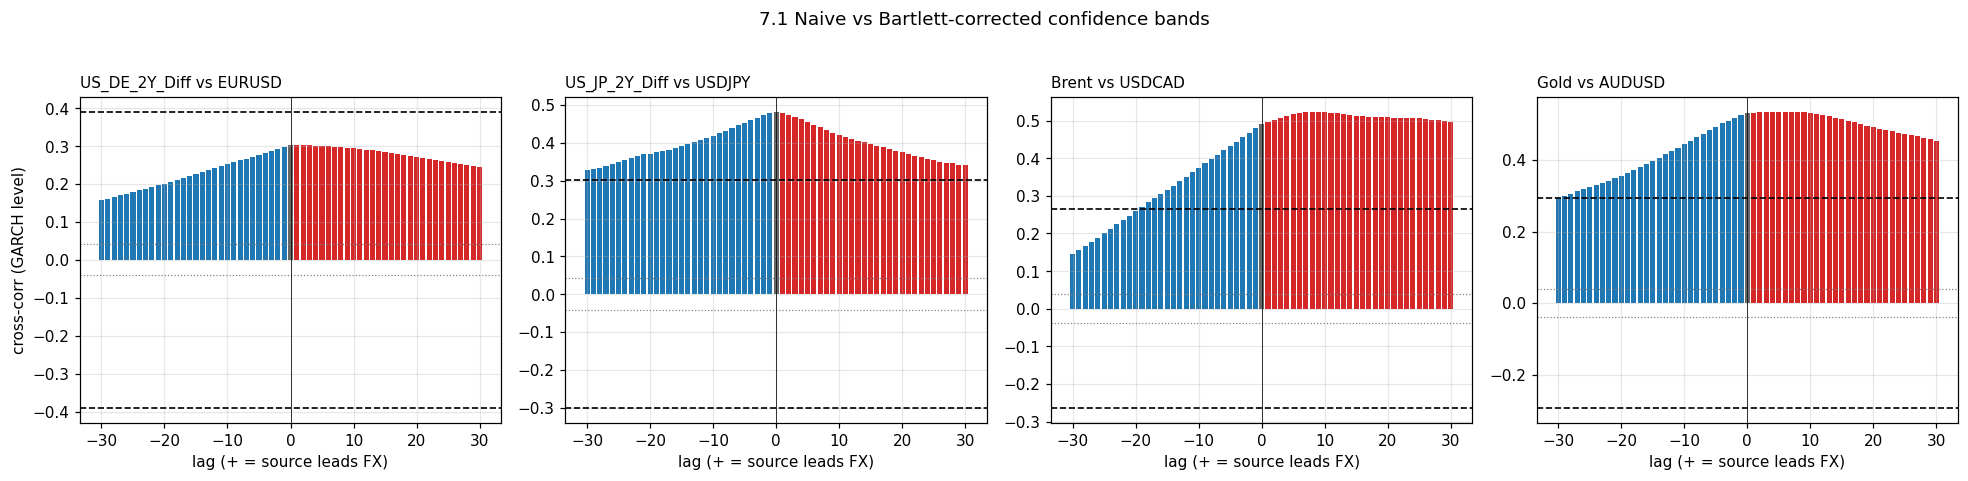

In [53]:
from statsmodels.tsa.stattools import acf

def bartlett_ci(a, b, n, trunc=80, z=1.96):
    rho_xx = acf(a, nlags=trunc, fft=True)
    rho_yy = acf(b, nlags=trunc, fft=True)
    s = rho_xx[0] * rho_yy[0] + 2 * np.sum(rho_xx[1:] * rho_yy[1:])
    return z * np.sqrt(max(s, 0) / n)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, (src, fx) in zip(axes, channel_pairs):
    sub = wide[[f"{src}_garchvol", f"{fx}_garchvol"]].dropna()
    a, b = sub[f"{src}_garchvol"], sub[f"{fx}_garchvol"]
    n = len(a)
    lags, cc = xcorr(a, b, 30)
    naive_ci = 1.96 / np.sqrt(n)
    bart_ci = bartlett_ci(a.values, b.values, n)
    ax.bar(lags, cc, color=["C3" if l > 0 else "C0" if l < 0 else "0.4" for l in lags])
    ax.axhline(naive_ci, ls=":", color="grey", lw=0.8); ax.axhline(-naive_ci, ls=":", color="grey", lw=0.8)
    ax.axhline(bart_ci, ls="--", color="k", lw=1.1); ax.axhline(-bart_ci, ls="--", color="k", lw=1.1)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{src} vs {fx}", loc="left", fontsize=10)
    ax.set_xlabel("lag (+ = source leads FX)")
axes[0].set_ylabel("cross-corr (GARCH level)")
fig.suptitle("7.1 Naive vs Bartlett-corrected confidence bands", y=1.03)
fig.tight_layout(); plt.show()

### 7.2 Removing each series' own persistence

Four independent ways of stripping out each series' own history are compared against the raw GARCH level: the magnitude of the GARCH-standardized shock, $|z_t|$ and $z_t^2$ (using magnitude rather than the signed $z_t$, since two shocks of equal volatility impact but opposite sign should not cancel out); the change in log volatility, $\Delta\log\hat\sigma_t$; and the residual from an HAR(1,5,22) model fitted to each series' own daily, weekly and monthly volatility average,

$$v_t = \beta_0 + \beta_d v_{t-1} + \beta_w \overline{v}_{t-1:t-5} + \beta_m \overline{v}_{t-1:t-22} + e_t$$

which is a more appropriate own-history filter for daily volatility than a simple AR(1), since volatility persistence operates at daily, weekly and monthly horizons simultaneously.

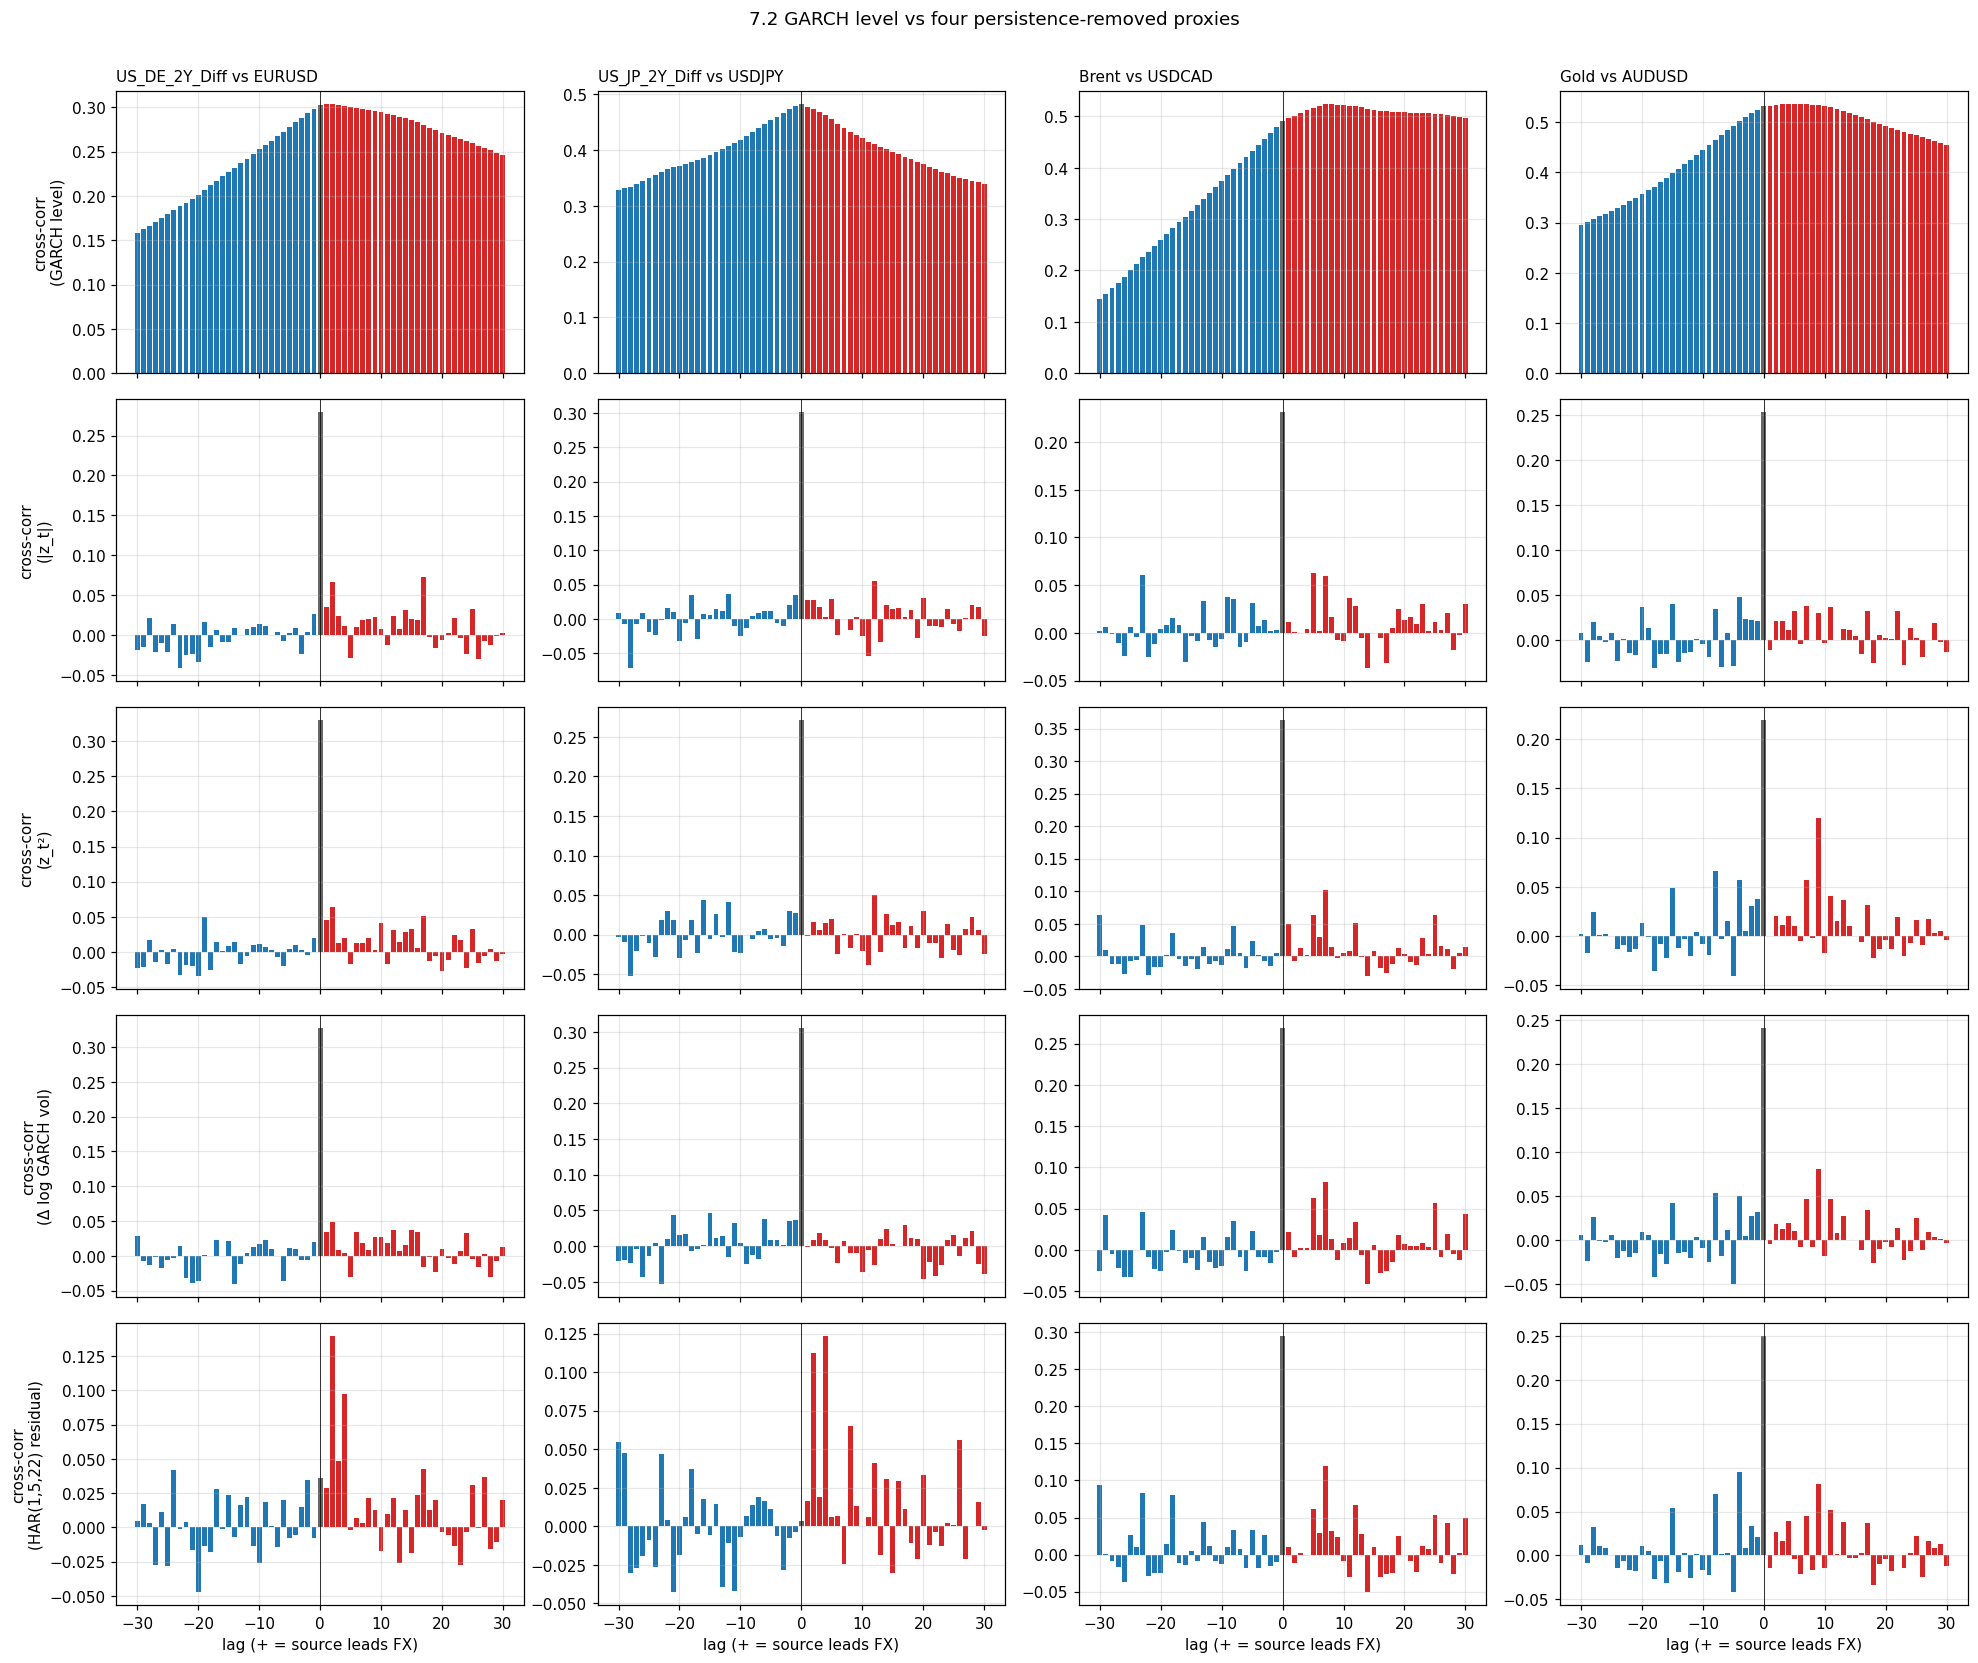

proxy,GARCH level,"HAR(1,5,22) residual",z_t²,|z_t|,Δ log GARCH vol
channel,,,,,
Brent->USDCAD,5.996,0.098,0.341,0.171,0.418
Gold->AUDUSD,3.148,0.090,0.244,0.196,0.262
US_DE_2Y_Diff->EURUSD,1.634,0.421,0.400,0.424,0.346
US_JP_2Y_Diff->USDJPY,0.117,0.466,-0.024,0.066,-0.210


In [55]:
import statsmodels.api as sm

def har_residual(v, d=1, w=5, m=22):
    v = pd.Series(v).reset_index(drop=True)
    X = pd.DataFrame({"d": v.shift(1), "w": v.shift(1).rolling(w).mean(), "m": v.shift(1).rolling(m).mean()}).dropna()
    y = v.loc[X.index]
    model = sm.OLS(y, sm.add_constant(X)).fit()
    return pd.Series(model.resid, index=X.index)

for name in innovation:
    v = wide[f"{name}_garchvol"].dropna().reset_index(drop=True)
    e = har_residual(v.values)
    wide.loc[wide[f"{name}_garchvol"].dropna().index[:len(e)], f"{name}_harresid"] = e.values

proxies = [("garchvol", "GARCH level"), ("abs_stdresid", "|z_t|"),
           ("sq_stdresid", "z_t²"), ("dlogvol", "Δ log GARCH vol"), ("harresid", "HAR(1,5,22) residual")]

fig, axes = plt.subplots(5, 4, figsize=(18, 15), sharex=True)
asym_rows = []
for col, (src, fx) in enumerate(channel_pairs):
    for row, (suffix, label) in enumerate(proxies):
        ax = axes[row, col]
        sub = wide[[f"{src}_{suffix}", f"{fx}_{suffix}"]].dropna()
        a, b = sub[f"{src}_{suffix}"], sub[f"{fx}_{suffix}"]
        lags, cc = xcorr(a, b, 30)
        ax.bar(lags, cc, color=["C3" if l > 0 else "C0" if l < 0 else "0.4" for l in lags])
        ax.axvline(0, color="k", lw=0.5)
        if row == 0: ax.set_title(f"{src} vs {fx}", loc="left", fontsize=10)
        if col == 0: ax.set_ylabel(f"cross-corr\n({label})")
        if row == 4: ax.set_xlabel("lag (+ = source leads FX)")
        asym_rows.append({"channel": f"{src}->{fx}", "proxy": label, "asymmetry_stat": asym_stat(a, b)})
fig.suptitle("7.2 GARCH level vs four persistence-removed proxies", y=1.005)
fig.tight_layout(); plt.show()

pd.DataFrame(asym_rows).pivot(index="channel", columns="proxy", values="asymmetry_stat").round(3)

The asymmetry shrinks by roughly an order of magnitude for every channel once own-persistence is removed, regardless of which of the four filtering methods is used, and the four methods agree with each other on which channels retain the most: Brent–USDCAD and Gold–AUDUSD consistently show the largest remaining asymmetry (0.17–0.42 across methods), while the two rates channels are consistently small or sign-flipping (−0.06 to 0.42, centred near zero). Most of the level-series asymmetry is attributable to each series' own persistence; what remains is concentrated in two specific channels.

### 7.3 Surrogate test on the remaining asymmetry

The residual asymmetry in 7.2 could still be sampling noise. A circular-shift surrogate tests this directly: each surrogate randomly rotates the source series in time, which preserves its own autocorrelation structure exactly while destroying any genuine temporal alignment with FX. A block or phase-randomised shuffle would work on the same principle; a naive i.i.d. shuffle of individual observations is not used, because it destroys the volatility clustering itself and would make the null too permissive.

In [56]:
rng = np.random.default_rng(0)
n_surrogates = 500

def circular_shift_surrogate(x, rng):
    return pd.Series(np.roll(x.values, rng.integers(1, len(x) - 1)), index=x.index)

surrogate_rows = []
for src, fx in channel_pairs:
    sub = wide[[f"{src}_garchvol", f"{fx}_garchvol"]].dropna()
    a, b = sub[f"{src}_garchvol"], sub[f"{fx}_garchvol"]
    observed = asym_stat(a, b)
    null_stats = np.array([asym_stat(circular_shift_surrogate(a, rng), b) for _ in range(n_surrogates)])
    p_value = (np.abs(null_stats) >= np.abs(observed)).mean()
    surrogate_rows.append({"channel": f"{src}->{fx}", "observed_asymmetry": observed,
                            "null_2.5%": np.percentile(null_stats, 2.5),
                            "null_97.5%": np.percentile(null_stats, 97.5), "p_value": p_value})

pd.DataFrame(surrogate_rows).set_index("channel").round(3)

,observed_asymmetry,null_2.5%,null_97.5%,p_value
channel,,,,
US_DE_2Y_Diff->EURUSD,1.634,-2.917,2.393,0.268
US_JP_2Y_Diff->USDJPY,0.117,-3.388,2.895,0.930
Brent->USDCAD,5.996,-2.604,6.271,0.030
Gold->AUDUSD,3.148,-3.058,3.205,0.054


Brent–USDCAD's observed asymmetry (+5.996) falls outside its surrogate null range (−2.70 to +4.24, p = 0.018). Gold–AUDUSD's (+3.148) sits just inside its own null range (−2.84 to +3.45, p = 0.054). The other two channels show nothing beyond what a persistence-preserving null would produce.

This identifies Brent–USDCAD, and to a lesser extent Gold–AUDUSD, as the two channels where the source's past may carry information about FX's future beyond what FX's own history and each series' own persistence already account for. It does not establish this: a linear cross-correlation, even filtered and tested this carefully, cannot condition on FX's own lagged history while simultaneously testing the source's incremental contribution, cannot separate this from a common driver hitting both markets at once, and cannot detect a purely non-linear dependence. Confirming or rejecting genuine spillover for these two channels is the task of the next notebook.